In [89]:
import os
import random
import numpy as np  
from pylab import mpl, plt  
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'
os.environ['PYTHONHASHSEED'] = '0'

In [90]:
x = np.linspace(0, 10)

In [91]:
def set_seeds(seed=100):
    random.seed(seed)
    np.random.seed(seed)
set_seeds()

In [ ]:
y = x + np.random.standard_normal(len(x))


In [93]:
reg = np.polyfit(x, y, deg=1)

In [94]:
reg

array([0.94612934, 0.22855261])

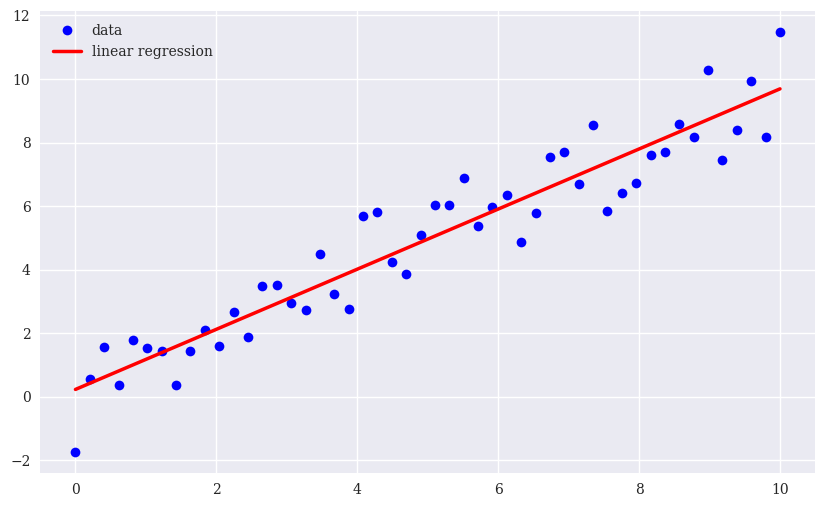

In [95]:
plt.figure(figsize=(10,6))
plt.plot(x,y,'bo', label='data')
plt.plot(x,np.polyval(reg,x), 'r', lw=2.5,
         label='linear regression')
plt.legend(loc=0)

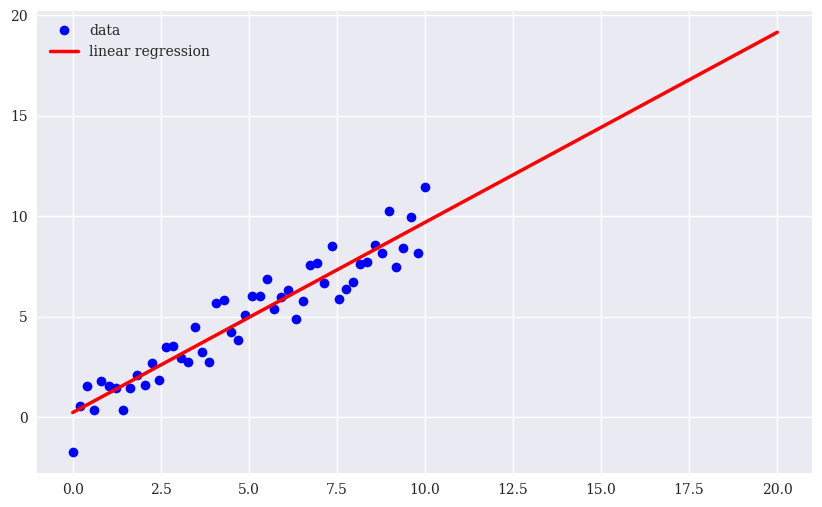

In [96]:
plt.figure(figsize=(10,6))
plt.plot(x,y,'bo',label='data')
xn = np.linspace(0,20)
plt.plot(xn,np.polyval(reg,xn), 'r', lw=2.5,
         label='linear regression')
plt.legend(loc=0);

In [97]:
x = np.arange(12)

In [98]:
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [99]:
lags = 3

In [100]:
m = np.zeros((lags+1, len(x) - lags))

In [101]:
m[lags] = x[lags:]
for i in range(lags):
    m[i] = x[i:i - lags]


In [102]:
m

array([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
       [ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
       [ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]])

In [103]:
m.T

array([[ 0.,  1.,  2.,  3.],
       [ 1.,  2.,  3.,  4.],
       [ 2.,  3.,  4.,  5.],
       [ 3.,  4.,  5.,  6.],
       [ 4.,  5.,  6.,  7.],
       [ 5.,  6.,  7.,  8.],
       [ 6.,  7.,  8.,  9.],
       [ 7.,  8.,  9., 10.],
       [ 8.,  9., 10., 11.]])

In [104]:
reg = np.linalg.lstsq(m[:lags].T, m[lags], rcond=None)[0]

In [105]:
reg

array([-0.66666667,  0.33333333,  1.33333333])

In [106]:
np.dot(m[:lags].T, reg)

array([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

In [107]:
import pandas as pd

In [108]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                           index_col=0, parse_dates=True).dropna()

In [109]:
symbol = 'EUR='

In [110]:
data = pd.DataFrame(raw[symbol])

In [111]:
data.rename(columns={symbol: 'price'}, inplace=True)


In [112]:
lags = 5

In [113]:
cols = []
for lag in range(1,lags + 1):
    col = f'lag_{lag}'
    data[col] = data['price'].shift(lag)
    cols.append(col)
data.dropna(inplace=True)

In [114]:
data.head()


,price,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-11,1.4513,1.4412,1.4318,1.4412,1.4368,1.4411
2010-01-12,1.4494,1.4513,1.4412,1.4318,1.4412,1.4368
2010-01-13,1.4510,1.4494,1.4513,1.4412,1.4318,1.4412
2010-01-14,1.4502,1.4510,1.4494,1.4513,1.4412,1.4318
2010-01-15,1.4382,1.4502,1.4510,1.4494,1.4513,1.4412


In [115]:
reg = np.linalg.lstsq(data[cols], data['price'],
                      rcond=None)[0]

In [116]:
reg

array([ 0.98635864,  0.02292172, -0.04769849,  0.05037365, -0.01208135])

In [117]:
data['prediction'] = np.dot(data[cols].values, reg)


<Axes: xlabel='Date'>

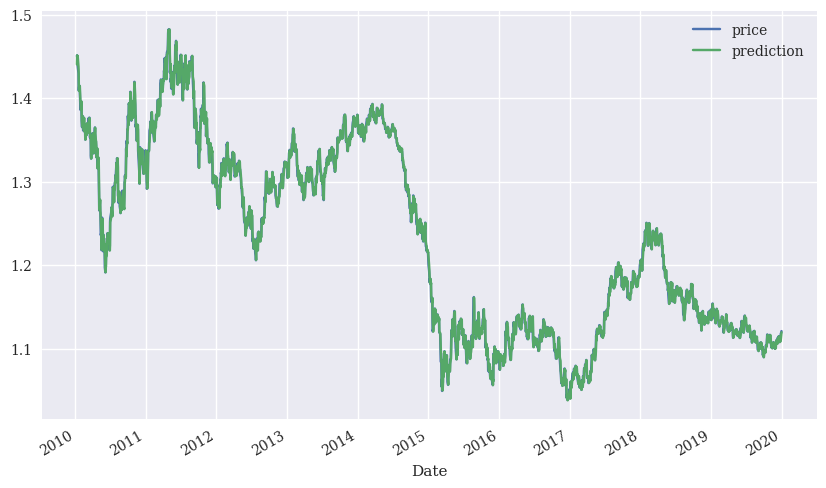

In [118]:
data[['price', 'prediction']].plot(figsize=(10,6))

<Axes: xlabel='Date'>

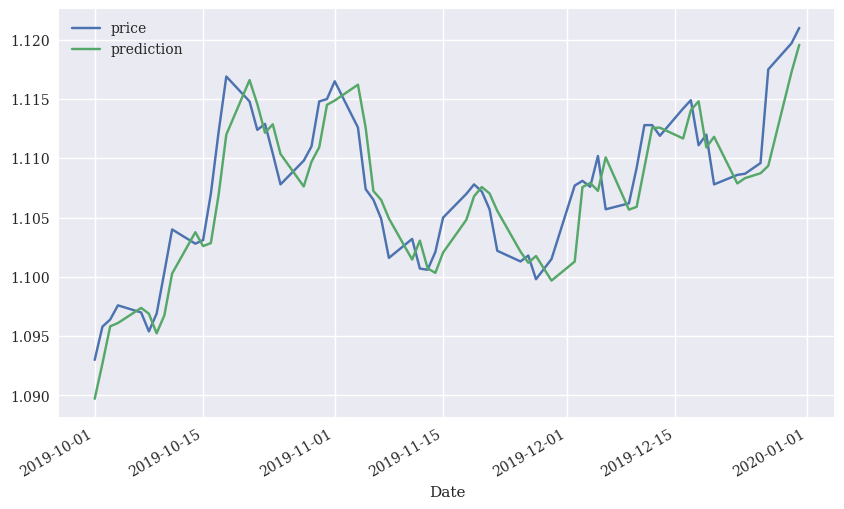

In [119]:
data[['price', 'prediction']].loc['2019-10-1':].plot(figsize=(10,6))

In [120]:
data['return'] = np.log(data['price'] / 
                        data['price'].shift(1))

In [121]:
data.dropna(inplace=True)

In [123]:
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['return'].shift(lag)
    cols.append(col)
data.dropna(inplace=True)


In [124]:
reg = np.linalg.lstsq(data[cols], data['return'],
                      rcond=None)[0]

In [125]:
reg

array([-0.015689  ,  0.00890227, -0.03634858,  0.01290924, -0.00636023])

In [126]:
data['prediction'] = np.dot(data[cols], reg)

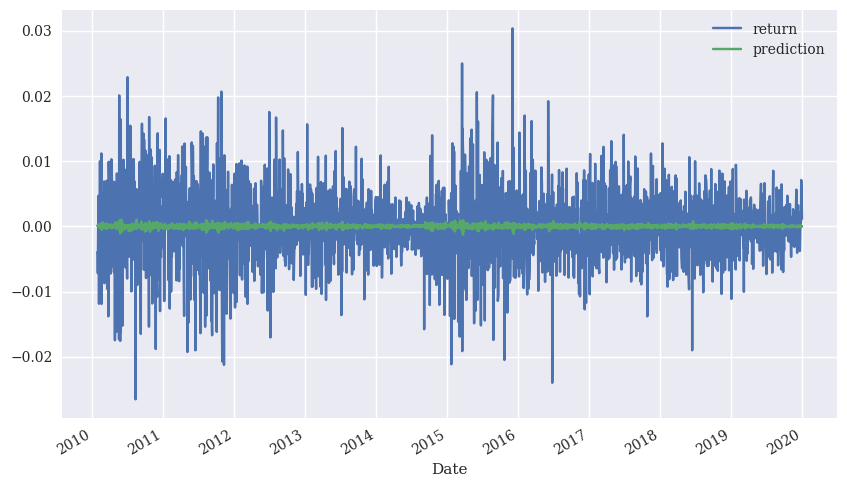

In [127]:
data[['return', 'prediction']].iloc[lags:].plot(figsize=(10,6));

In [130]:
hits = np.sign(data['return'] * data['prediction']).value_counts()

In [131]:
hits

 1.0    1250
-1.0    1242
 0.0      13
Name: count, dtype: int64

In [132]:
hits.values[0] / sum(hits)

np.float64(0.499001996007984)

In [133]:
reg = np.linalg.lstsq(data[cols], np.sign(data['return']),
                      rcond=None)[0]

In [134]:
reg

array([-5.11938725, -2.24077248, -5.13080606, -3.03753232, -2.14819119])

In [135]:
data['prediction'] = np.sign(np.dot(data[cols], reg))

In [136]:
data['prediction'].value_counts()

prediction
 1.0    1300
-1.0    1205
Name: count, dtype: int64

In [137]:
hits = np.sign(data['return'] *
               data['prediction']).value_counts()

In [138]:
hits

 1.0    1301
-1.0    1191
 0.0      13
Name: count, dtype: int64

In [139]:
hits.values[0] / sum(hits)

np.float64(0.5193612774451097)

In [140]:
data.head()

,price,lag_1,lag_2,lag_3,lag_4,lag_5,prediction,return
Date,,,,,,,,
2010-01-20,1.4101,-0.005858,-0.008309,-0.000551,0.001103,-0.001310,1.0,-0.013874
2010-01-21,1.4090,-0.013874,-0.005858,-0.008309,-0.000551,0.001103,1.0,-0.000780
2010-01-22,1.4137,-0.000780,-0.013874,-0.005858,-0.008309,-0.000551,1.0,0.003330
2010-01-25,1.4150,0.003330,-0.000780,-0.013874,-0.005858,-0.008309,1.0,0.000919
2010-01-26,1.4073,0.000919,0.003330,-0.000780,-0.013874,-0.005858,1.0,-0.005457


In [141]:
data['strategy'] = data['prediction'] * data['return']

In [142]:
data[['return', 'strategy']].sum().apply(np.exp)

return      0.784026
strategy    1.654154
dtype: float64

<Axes: xlabel='Date'>

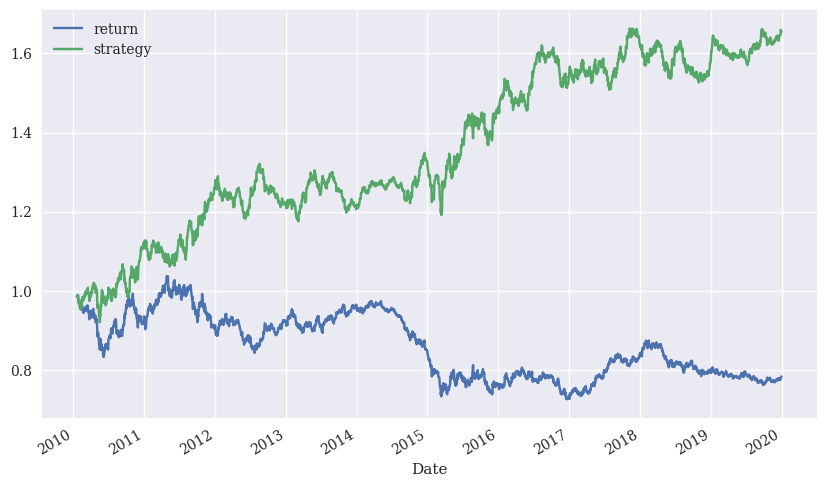

In [152]:
data[['return', 'strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(10,6))